## Colab y librerías

In [1]:
from google.colab import drive
drive.mount('/content/drive')

my_dir = "/content/drive/MyDrive/Master/DLTEMP/Proyecto/"

Mounted at /content/drive


In [2]:
!pip install -q pytorch-lightning

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 58.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 70.6 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
import pytorch_lightning as pl
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint

## 1. Dataset

#### 1.1 Lectura y definición del Dataset

Este trabajo será sobre predicción (Probabilistic forecasting I: Temperature), un problema de predicción utilizando intervalos de confianza.  
Se utilizará el conjunto de datos de entrenamiento ("train.csv") para entrenar y validar los modelos. Se trata de un conjunto de unos 64 mil registros, multivariante.  
La variable a predecir es la temperatura, por ello se creará una variable artificial de mes ("sin_month" y "cos_month") por si pudiese llegar a ser relevante y facilitar la predicción de sucesos estacionales.

In [ ]:
# Lectura
df = pd.read_csv(my_dir+"data/train.csv", parse_dates=["date"])
df.drop(columns=['id'], inplace=True)
df = df.sort_values("date").reset_index(drop=True)

# Añadir variable artificial de mes para capturar estacionalidad (si la hubiese)
df['month'] = df['date'].dt.month
df['sin_month'] = np.sin(2 * np.pi * (df['month'] / 12))
df['cos_month'] = np.cos(2 * np.pi * (df['month'] / 12))

print(df.info())
print('\n5 PRIMERAS FILAS:')
display(df.head())
print('\nESTADÍSTICOS:')
display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64320 entries, 0 to 64319
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         64320 non-null  datetime64[ns]
 1   feature_AA   64320 non-null  float64       
 2   feature_AB   64320 non-null  float64       
 3   feature_BA   64320 non-null  float64       
 4   feature_BB   64320 non-null  float64       
 5   feature_CA   64320 non-null  float64       
 6   feature_CB   64320 non-null  float64       
 7   Temperature  64320 non-null  float64       
 8   month        64320 non-null  int32         
 9   sin_month    64320 non-null  float64       
 10  cos_month    64320 non-null  float64       
dtypes: datetime64[ns](1), float64(9), int32(1)
memory usage: 5.2 MB
None

5 PRIMERAS FILAS:


,date,feature_AA,feature_AB,feature_BA,feature_BB,feature_CA,feature_CB,Temperature,month,sin_month,cos_month
0,2016-07-01 00:00:00,5.827,2.009,1.599,0.462,4.203,1.340,30.531000,7,-0.5,-0.866025
1,2016-07-01 00:15:00,5.760,2.076,1.492,0.426,4.264,1.401,30.459999,7,-0.5,-0.866025
2,2016-07-01 00:30:00,5.760,1.942,1.492,0.391,4.234,1.310,30.038000,7,-0.5,-0.866025
3,2016-07-01 00:45:00,5.760,1.942,1.492,0.426,4.234,1.310,27.013000,7,-0.5,-0.866025
4,2016-07-01 01:00:00,5.693,2.076,1.492,0.426,4.142,1.371,27.787001,7,-0.5,-0.866025



ESTADÍSTICOS:


,date,feature_AA,feature_AB,feature_BA,feature_BB,feature_CA,feature_CB,Temperature,month,sin_month,cos_month
count,64320,64320.000000,64320.000000,64320.000000,64320.000000,64320.000000,64320.000000,64320.000000,64320.000000,6.432000e+04,6.432000e+04
mean,2017-05-31 23:52:30,7.522545,2.142897,4.478698,0.820356,3.042537,0.819362,13.610430,6.617910,-2.825105e-02,8.096823e-02
min,2016-07-01 00:00:00,-21.568001,-5.693000,-23.986000,-6.041000,-1.188000,-1.371000,-4.221000,1.000000,-1.000000e+00,-1.000000e+00
25%,2016-12-15 11:56:15,5.961000,0.670000,3.553000,-0.391000,2.284000,0.640000,6.753000,3.000000,-8.660254e-01,-5.000000e-01
50%,2017-05-31 23:52:30,8.841000,2.076000,6.041000,0.853000,2.802000,0.944000,11.959000,7.000000,-2.449294e-16,6.123234e-17
75%,2017-11-15 11:48:45,11.721000,3.550000,8.635000,2.132000,3.594000,1.157000,18.712000,10.000000,8.660254e-01,8.660254e-01
max,2018-05-01 23:45:00,24.180000,10.315000,18.087000,7.853000,8.498000,3.046000,46.007000,12.000000,1.000000e+00,1.000000e+00
std,NaN,6.914888,2.023449,6.669074,1.818778,1.169700,0.602287,8.827735,3.581528,7.283910e-01,6.797853e-01


#### 1.2 Normalización del Dataset

Se normaliza el dataset para estabilizar y mejorar el entrenamiento.  

NOTA: se normaliza también la etiqueta y se recuperará el dato a la hora de graficar las predicciones

In [ ]:
# Normalización de variables
features = ["feature_AA","feature_AB","feature_BA","feature_BB","feature_CA","feature_CB","sin_month","cos_month"]
target = "Temperature"

# División en entrenamiento y validación
train_size = int(len(df)*0.7)
val_size = int(len(df)*0.3)

df_train = df.iloc[:train_size].copy()
df_val = df.iloc[train_size:].copy()

# Normalización
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

df_train[features] = scaler_X.fit_transform(df_train[features])
df_val[features] = scaler_X.transform(df_val[features])

df_train[target] = scaler_y.fit_transform(df_train[[target]])
df_val[target] = scaler_y.transform(df_val[[target]])

In [6]:
print('\nESTADÍSTICOS:')
display(df_train.describe())


ESTADÍSTICOS:


,date,feature_AA,feature_AB,feature_BA,feature_BB,feature_CA,feature_CB,Temperature,month,sin_month,cos_month
count,45024,45024.000000,45024.000000,45024.000000,45024.000000,45024.000000,45024.000000,45024.000000,45024.000000,45024.000000,45024.000000
mean,2017-02-20 11:52:30,0.638651,0.474095,0.682187,0.481518,0.428362,0.481186,0.420995,6.901919,0.409698,0.460327
min,2016-07-01 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,2016-10-26 05:56:15,0.604682,0.368191,0.657952,0.373399,0.349061,0.448268,0.299713,4.000000,0.066987,0.066987
50%,2017-02-20 11:52:30,0.658848,0.464393,0.709457,0.483374,0.402540,0.517319,0.400553,7.000000,0.250000,0.500000
75%,2017-06-17 17:48:45,0.718895,0.569028,0.768593,0.590831,0.478009,0.572334,0.504201,9.000000,0.750000,0.750000
max,2017-10-12 23:45:00,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,12.000000,1.000000,1.000000
std,NaN,0.137023,0.134133,0.143585,0.141355,0.127268,0.154344,0.166268,3.157417,0.355026,0.337985


#### 1.3 Clase del Dataset

Se define la clase del Dataset que se utilizará en el entrenamiento de los modelos.

In [ ]:
class TimeSeriesDataset(Dataset):
    def __init__(self, df, features, target, encoder_length=30, decoder_length=7):
        self.X = df[features].values
        self.y = df[target].values
        self.encoder_length = encoder_length
        self.decoder_length = decoder_length

    def __len__(self):
        return len(self.X) - self.encoder_length - self.decoder_length + 1

    def __getitem__(self, idx):
        x_enc = self.X[idx: idx+self.encoder_length]
        x_dec = self.X[idx+self.encoder_length : idx+self.encoder_length+self.decoder_length]
        y_dec = self.y[idx+self.encoder_length : idx+self.encoder_length+self.decoder_length]

        return {
            "encoder_x": torch.tensor(x_enc, dtype=torch.float),
            "decoder_x": torch.tensor(x_dec, dtype=torch.float),
            "decoder_y": torch.tensor(y_dec, dtype=torch.float)
        }

## 2. Función de pérdida

Se define la función de pérdida basada en cuantiles. En el contexto del problema, se define la predicción utilizando intervalos de confianza.  
Se propone la siguiente función de pérdida:  
> MAX[(q-1)*(valor_real-predicción), q*(valor_real-predicción)]  

Donde los cuantiles más bajos penalizarán más aquellas predicciones que se queden por encima del valor real, mientras que los cuantiles más altos penalizarán más el caso contrario, cuando las predicciones se queden por debajo del valor real. Esto dará un umbral que será nuestro intervalo de confianza.

In [ ]:
class QuantileLoss(nn.Module):
    def __init__(self, quantiles):
        super().__init__()
        self.quantiles = quantiles

    def forward(self, preds, target):
        losses = []
        for i, q in enumerate(self.quantiles):
            errors = target - preds[:,:,i]
            loss = torch.max((q-1)*errors, q*errors)
            losses.append(loss.unsqueeze(-1))
        return torch.mean(torch.cat(losses, dim=-1))

## 3. Infraestructura de los modelos

Se entrenarán los siguientes de modelos para posteriormente comparar los resultados.  
- MLP
- LSTM
- GRU
- TCN
- Transformer

#### 3.1 MLP

Se utilizará un perceptón multicapa como baseline respecto el resto de modelos.

In [ ]:
class MLPModel(pl.LightningModule):
    def __init__(self, input_size, hidden_size, encoder_length, decoder_length, quantiles, lr=1e-3):
        super().__init__()

        total_input = input_size * (encoder_length + decoder_length)

        self.net = nn.Sequential(
            nn.Linear(total_input, hidden_size),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, decoder_length * len(quantiles))
        )

        self.decoder_length = decoder_length
        self.quantiles = quantiles
        self.loss_fn = QuantileLoss(quantiles)
        self.lr = lr

    def forward(self, x_enc, x_dec):
        x = torch.cat([x_enc, x_dec], dim=1)
        x = x.view(x.size(0), -1)
        out = self.net(x)
        out = out.view(-1, self.decoder_length, len(self.quantiles))
        return out

    def training_step(self, batch, batch_idx):
        y_hat = self(batch["encoder_x"], batch["decoder_x"])
        loss = self.loss_fn(y_hat, batch["decoder_y"])
        self.log("train_loss", loss, prog_bar=True, on_step=False, on_epoch=True)
        return loss

    def validation_step(self, batch, batch_idx):
        y_hat = self(batch["encoder_x"], batch["decoder_x"])
        loss = self.loss_fn(y_hat, batch["decoder_y"])
        self.log("val_loss", loss, prog_bar=True, on_step=False, on_epoch=True)

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.lr)

#### 3.2 LSTM

Se entrenará una LSTM (Long Short-Term Memory).

In [ ]:
class LSTMModel(pl.LightningModule):
    def __init__(self, input_size, hidden_size, num_layers, decoder_length, quantiles, lr=1e-3):
        super().__init__()

        self.encoder = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.decoder = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, len(quantiles))

        self.loss_fn = QuantileLoss(quantiles)
        self.lr = lr

    def forward(self, x_enc, x_dec):
        _, (h, c) = self.encoder(x_enc)
        out_dec, _ = self.decoder(x_dec, (h, c))
        return self.fc(out_dec)

    def training_step(self, batch, batch_idx):
        y_hat = self(batch["encoder_x"], batch["decoder_x"])
        loss = self.loss_fn(y_hat, batch["decoder_y"])
        self.log("train_loss", loss, prog_bar=True, on_step=False, on_epoch=True)
        return loss

    def validation_step(self, batch, batch_idx):
        y_hat = self(batch["encoder_x"], batch["decoder_x"])
        loss = self.loss_fn(y_hat, batch["decoder_y"])
        self.log("val_loss", loss, prog_bar=True, on_step=False, on_epoch=True)

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.lr )

#### 3.3 GRU

Se entrenará una GRU (Gated Recurrent Unit). Esta es similar a la LSTM aunque con menos parámetros y más eficiente por tanto en el entrenamiento.  
Se comparará con la anterior para analizarlo en términos de eficiencia.

In [11]:
class GRUModel(pl.LightningModule):
    def __init__(self, input_size, hidden_size, num_layers, decoder_length, quantiles, lr=1e-3):
        super().__init__()

        self.encoder = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.decoder = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)

        self.fc = nn.Linear(hidden_size, len(quantiles))
        self.loss_fn = QuantileLoss(quantiles)
        self.lr = lr

    def forward(self, x_enc, x_dec):
        _, h = self.encoder(x_enc)
        out_dec, _ = self.decoder(x_dec, h)
        return self.fc(out_dec)

    def training_step(self, batch, batch_idx):
        y_hat = self(batch["encoder_x"], batch["decoder_x"])
        loss = self.loss_fn(y_hat, batch["decoder_y"])
        self.log("train_loss", loss, prog_bar=True, on_step=False, on_epoch=True)
        return loss

    def validation_step(self, batch, batch_idx):
        y_hat = self(batch["encoder_x"], batch["decoder_x"])
        loss = self.loss_fn(y_hat, batch["decoder_y"])
        self.log("val_loss", loss, prog_bar=True, on_step=False, on_epoch=True)

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.lr)

#### 3.4 TCN

Se entrenará una TCN (Temporal Convolutional Network), una red basada en convoluciones 1D y que puede ser aplicado a series temporales.

In [ ]:
class TCNBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, dilation=1, dropout=0.1):
        super().__init__()
        self.conv = nn.Conv1d(
            in_channels, out_channels,
            kernel_size=kernel_size,
            padding=(kernel_size-1)*dilation,
            dilation=dilation
        )
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = self.conv(x)
        x = x[:, :, : - (self.conv.padding[0])]
        x = self.relu(x)
        x = self.dropout(x)
        return x

class TCNModel(pl.LightningModule):
    def __init__(self, input_size, hidden_size, encoder_length, decoder_length, quantiles, lr=1e-3):
        super().__init__()

        self.tcn1 = TCNBlock(input_size, hidden_size, kernel_size=3, dilation=1)
        self.tcn2 = TCNBlock(hidden_size, hidden_size, kernel_size=3, dilation=2)
        self.fc = nn.Linear(hidden_size, len(quantiles))

        self.decoder_length = decoder_length
        self.loss_fn = QuantileLoss(quantiles)
        self.lr = lr

    def forward(self, x_enc, x_dec):
        x = torch.cat([x_enc, x_dec], dim=1)
        x = x.transpose(1, 2)
        x = self.tcn1(x)
        x = self.tcn2(x)
        x = x[:, :, -self.decoder_length:]
        x = x.transpose(1, 2)
        return self.fc(x)

    def training_step(self, batch, batch_idx):
        y_hat = self(batch["encoder_x"], batch["decoder_x"])
        loss = self.loss_fn(y_hat, batch["decoder_y"])
        self.log("train_loss", loss, prog_bar=True, on_step=False, on_epoch=True)
        return loss

    def validation_step(self, batch, batch_idx):
        y_hat = self(batch["encoder_x"], batch["decoder_x"])
        loss = self.loss_fn(y_hat, batch["decoder_y"])
        self.log("val_loss", loss, prog_bar=True, on_step=False, on_epoch=True)

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.lr)

#### 3.5 Transfomer

Se entrenará una red basada en transformers aplicada a series temporales.

In [ ]:
class TransformerModel(pl.LightningModule):
    def __init__(self, input_size, hidden_size, num_heads, num_layers,
                 encoder_length, decoder_length, quantiles, lr=1e-3):
        super().__init__()

        self.embedding = nn.Linear(input_size, hidden_size)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_size,
            nhead=num_heads,
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc_out = nn.Linear(hidden_size, len(quantiles))

        self.decoder_length = decoder_length
        self.loss_fn = QuantileLoss(quantiles)
        self.lr = lr

    def forward(self, x_enc, x_dec):
        x = torch.cat([x_enc, x_dec], dim=1)
        x = self.embedding(x)
        out = self.transformer_encoder(x)
        out = out[:, -self.decoder_length:, :]
        return self.fc_out(out)

    def training_step(self, batch, batch_idx):
        y_hat = self(batch["encoder_x"], batch["decoder_x"])
        loss = self.loss_fn(y_hat, batch["decoder_y"])
        self.log("train_loss", loss, prog_bar=True, on_step=False, on_epoch=True)
        return loss

    def validation_step(self, batch, batch_idx):
        y_hat = self(batch["encoder_x"], batch["decoder_x"])
        loss = self.loss_fn(y_hat, batch["decoder_y"])
        self.log("val_loss", loss, prog_bar=True, on_step=False, on_epoch=True)

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.lr)

## 4. Entrenamiento

Se define una función para el entrenamiento con Early Stopping y Checkpoint.

In [37]:
def train_model(model, train_loader, val_loader, model_name='model', max_epochs=100, patience=10):

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=patience,
        mode='min',
        min_delta=1e-4
    )

    checkpoint = ModelCheckpoint(
        monitor='val_loss',
        mode='min',
        save_top_k=1,
        save_last=True,
        filename=f'{model_name}-{{epoch:02d}}-{{val_loss:.2f}}',
        dirpath=my_dir+f'checkpoints/{model_name}'
    )

    trainer = pl.Trainer(
        max_epochs=max_epochs,
        accelerator="auto",
        devices="auto",
        gradient_clip_val=1.0,
        callbacks=[early_stop, checkpoint]
    )

    trainer.fit(model, train_dataloaders=train_loader, val_dataloaders=val_loader)

    return model

Se definen los hiperparámetros con los que se entrenarán los modelos.

In [ ]:
# Hiperparámetros
encoder_length = 90
decoder_length = 7
batch_size = 128
quantiles = [0.1, 0.25, 0.5, 0.75, 0.95]

train_dataset = TimeSeriesDataset(df_train, features, target, encoder_length, decoder_length)
val_dataset = TimeSeriesDataset(df_val, features, target, encoder_length, decoder_length)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

#### 4.1 Entrenamiento de MLP

In [ ]:
mlp_model = MLPModel(
    input_size=len(features),
    encoder_length=encoder_length,
    decoder_length=decoder_length,
    quantiles=quantiles,
    hidden_size=128,
    lr=1e-4
)

mlp_model = train_model(
    mlp_model,
    train_loader=train_loader,
    val_loader=val_loader,
    model_name='mlp',
)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type         ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ net     │ Sequential   │  120 K │ train │     0 │
│ 1 │ loss_fn │ QuantileLoss │      0 │ train │     0 │
└───┴─────────┴──────────────┴────────┴───────┴───────┘

Trainable params: 120 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 120 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 8                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

#### 4.2 Entrenamiento de LSTM

In [ ]:
lstm_model = LSTMModel(
    input_size=len(features),
    decoder_length=decoder_length,
    quantiles=quantiles,
    hidden_size=128,
    num_layers=3,
    lr=1e-4
)

lstm_model = train_model(
    lstm_model,
    train_loader=train_loader,
    val_loader=val_loader,
    model_name='lstm',
)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type         ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ encoder │ LSTM         │  334 K │ train │     0 │
│ 1 │ decoder │ LSTM         │  334 K │ train │     0 │
│ 2 │ fc      │ Linear       │    645 │ train │     0 │
│ 3 │ loss_fn │ QuantileLoss │      0 │ train │     0 │
└───┴─────────┴──────────────┴────────┴───────┴───────┘

Trainable params: 670 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 670 K                                                                                                
Total estimated model params size (MB): 2                                                                          
Modules in train mode: 4                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

#### 4.3 Entrenamiento de GRU

In [ ]:
gru_model = GRUModel(
    input_size=len(features),
    decoder_length=decoder_length,
    quantiles=quantiles,
    hidden_size=128,
    num_layers=3,
    lr=1e-4
)

gru_model = train_model(
    gru_model,
    train_loader=train_loader,
    val_loader=val_loader,
    model_name='gru',
)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /content/drive/MyDrive/Master/DLTEMP/Proyecto/checkpoints/gru exists and is not empty.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type         ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ encoder │ GRU          │  251 K │ train │     0 │
│ 1 │ decoder │ GRU          │  251 K │ train │     0 │
│ 2 │ fc      │ Linear       │    645 │ train │     0 │
│ 3 │ loss_fn │ QuantileLoss │      0 │ train │     0 │
└───┴─────────┴──────────────┴────────┴───────┴───────┘

Trainable params: 502 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 502 K                                                                                                
Total estimated model params size (MB): 2                                                                          
Modules in train mode: 4                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

#### 4.4 Entrenamiento de TCN

In [ ]:
tcn_model = TCNModel(
    input_size=len(features),
    encoder_length=encoder_length,
    decoder_length=decoder_length,
    quantiles=quantiles,
    hidden_size=128,
    lr=1e-4
)

tcn_model = train_model(
    tcn_model,
    train_loader=train_loader,
    val_loader=val_loader,
    model_name='tcn',
)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type         ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ tcn1    │ TCNBlock     │  3.2 K │ train │     0 │
│ 1 │ tcn2    │ TCNBlock     │ 49.3 K │ train │     0 │
│ 2 │ fc      │ Linear       │    645 │ train │     0 │
│ 3 │ loss_fn │ QuantileLoss │      0 │ train │     0 │
└───┴─────────┴──────────────┴────────┴───────┴───────┘

Trainable params: 53.1 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 53.1 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 10                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

#### 4.5 Entrenamiento de Transformer

In [ ]:
tfrmer_model = TransformerModel(
    input_size=len(features),
    encoder_length=encoder_length,
    decoder_length=decoder_length,
    quantiles=quantiles,
    hidden_size=128,
    num_heads=4,
    num_layers=3,
    lr=1e-4
)

tfrmer_model = train_model(
    tfrmer_model,
    train_loader=train_loader,
    val_loader=val_loader,
    model_name='tfrmer',
)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name                ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ embedding           │ Linear             │  1.2 K │ train │     0 │
│ 1 │ transformer_encoder │ TransformerEncoder │  1.8 M │ train │     0 │
│ 2 │ fc_out              │ Linear             │    645 │ train │     0 │
│ 3 │ loss_fn             │ QuantileLoss       │      0 │ train │     0 │
└───┴─────────────────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 1.8 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 1.8 M                                                                                                
Total estimated model params size (MB): 7                                                                          
Modules in train mode: 35                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

## 5. Visualización de resultados

Se define una función para llegar a la predicción de la temperatura para cada cuantil.

In [ ]:
def predict_quantiles(model, dataset, batch_size=64):
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    all_preds = []
    model.eval()
    with torch.no_grad():
        for batch in loader:
            x_enc = batch["encoder_x"].to(model.device)
            x_dec = batch["decoder_x"].to(model.device)
            y_hat = model(x_enc, x_dec).cpu().numpy()
            all_preds.append(y_hat)
    return np.concatenate(all_preds, axis=0)

Se define una función para deshacer la normalización (desnormalizar) y recuperar la predicción en la escala del dato original.

In [ ]:
def desnormalize_preds(y_scaled, scaler_y):
    shape = y_scaled.shape
    y_flat = y_scaled.reshape(-1, y_scaled.shape[-1])
    y_real_flat = scaler_y.inverse_transform(y_flat)
    return y_real_flat.reshape(shape)

Se define una función para graficar los modelos de los "n_steps" primeros datos.  
Además se da la opción de pintar el intervalo de confianza con "print_trhold".

In [ ]:
def plot_models(preds_dict, real_series, quantiles=[0.1,0.5,0.95], n_steps=1000, print_trhold=False):
    """
    preds_dict: dict de {nombre_modelo: preds_desnormalizados}
    real_series: array con valores reales
    """
    plt.figure(figsize=(14,6))
    plt.plot(real_series[:n_steps], label="Real", color="black", linewidth=2)

    for name, preds in preds_dict.items():
        median = preds[:, 0, quantiles.index(0.5)]
        q_low = preds[:, 0, quantiles.index(0.1)]
        q_high = preds[:, 0, quantiles.index(0.95)]

        plt.plot(median[:n_steps], label=f"{name} mediana")
        if print_trhold:
            plt.fill_between(np.arange(min(n_steps, len(median))),
                            q_low[:n_steps], q_high[:n_steps],
                            alpha=0.2)

    plt.title("Predicciones cuantílicas de modelos")
    plt.xlabel("Tiempo")
    plt.ylabel("Temperature")
    plt.legend()
    plt.show()

Se aplican las anteriores funciones comentadas para cada modelo.

In [ ]:
models = {
    "LSTM": lstm_model,
    "GRU": gru_model,
    "MLP": mlp_model,
    "TCN": tcn_model,
    "Transformer": tfrmer_model
}

preds_dict = {}
for name, model in models.items():
    preds_scaled = predict_quantiles(model, dataset=val_dataset)
    preds_dict[name] = desnormalize_preds(preds_scaled, scaler_y)

Se grafican las predicciones de los 1000 primeros datos del conjunto de validación y la predicción de cada modelo para el cuantil 0.5 (mediana).

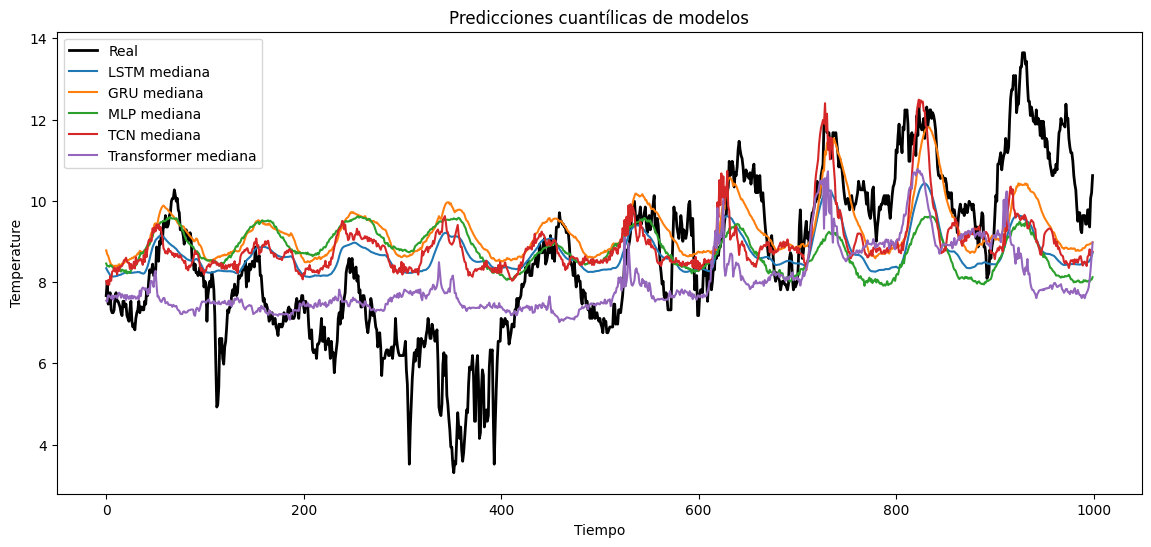

In [ ]:
real_series_val = scaler_y.inverse_transform(df_val[target].values.reshape(-1,1)).flatten()
plot_models(preds_dict, real_series=real_series_val, quantiles=[0.1,0.5,0.95], n_steps=1000)

Parece que hay modelos que logran predecir mejor que otros los picos en algunos puntos mientras que otros están más estables. Además, parece haber problemas en general al predecir cuando la temperatura baja repentinamente.  
Veámoslo por modelo.

#### 5.1 Visualización de la MLP

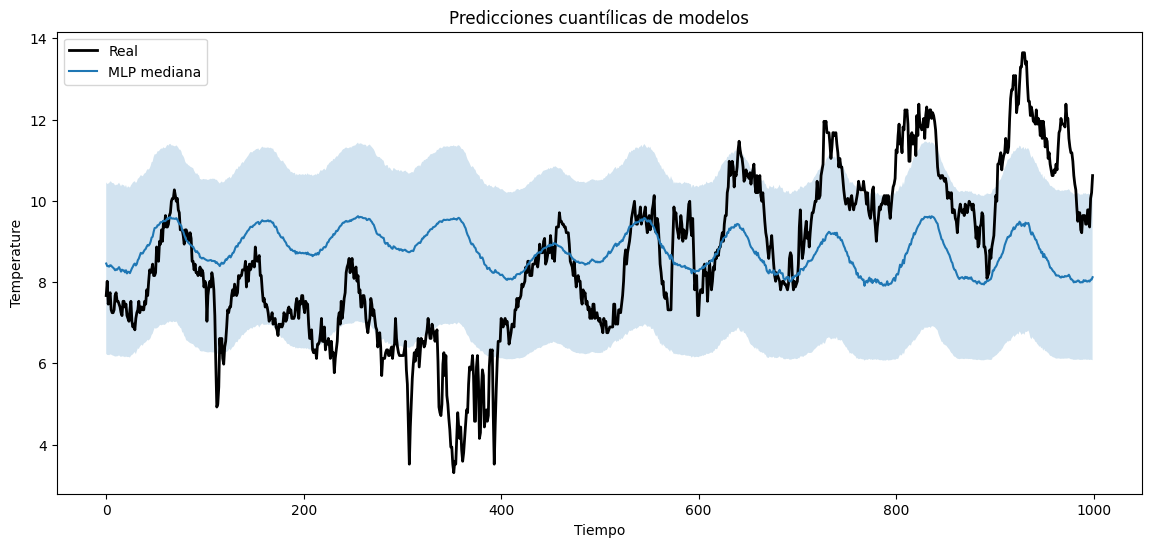

In [53]:
plot_models({'MLP': preds_dict['MLP']}, real_series=real_series_val, quantiles=[0.1,0.5,0.95], n_steps=1000, print_trhold=True)

La predicción que devuelve la MLP queda demasiado estable sin llegar a acercarse a los picos. Esto puede ser normal ya que es el modelo más sencillo de todos y el que se utilizaba de baseline.

#### 5.2 Visualización de la LTSM

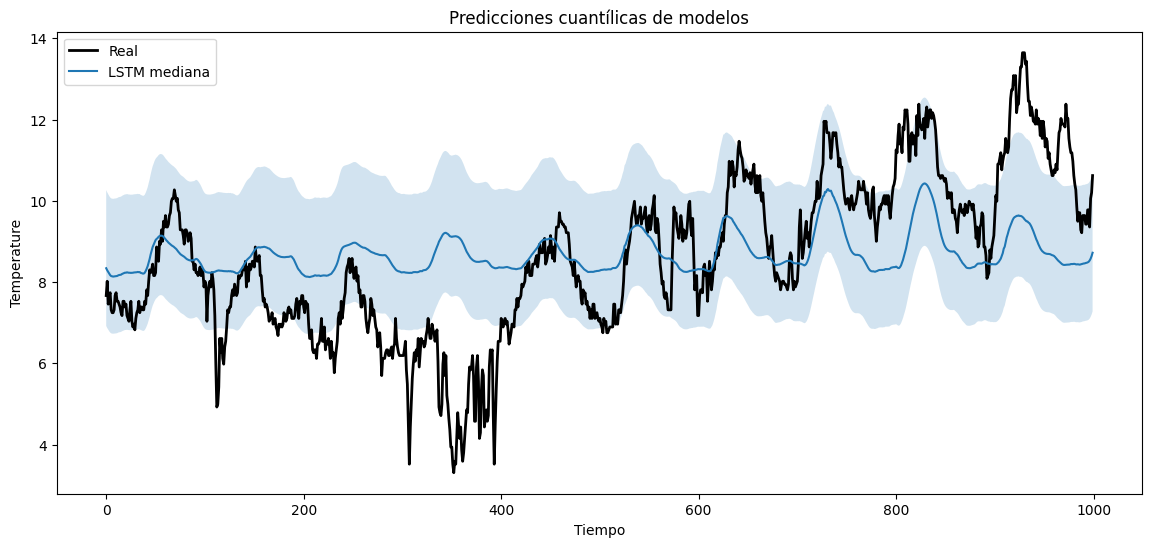

In [52]:
plot_models({'LSTM': preds_dict['LSTM']}, real_series=real_series_val, quantiles=[0.1,0.5,0.95], n_steps=1000, print_trhold=True)

La LTSM mejora los resultados del baseline y ya el intervalo de confianza contiene estos picos repentinos en la temperatura. Sin embargo sigue habiendo problemas especialmente cuando la temperatura tiene bajadas como en el del paso 400.

#### 5.3 Visualización de la GRU

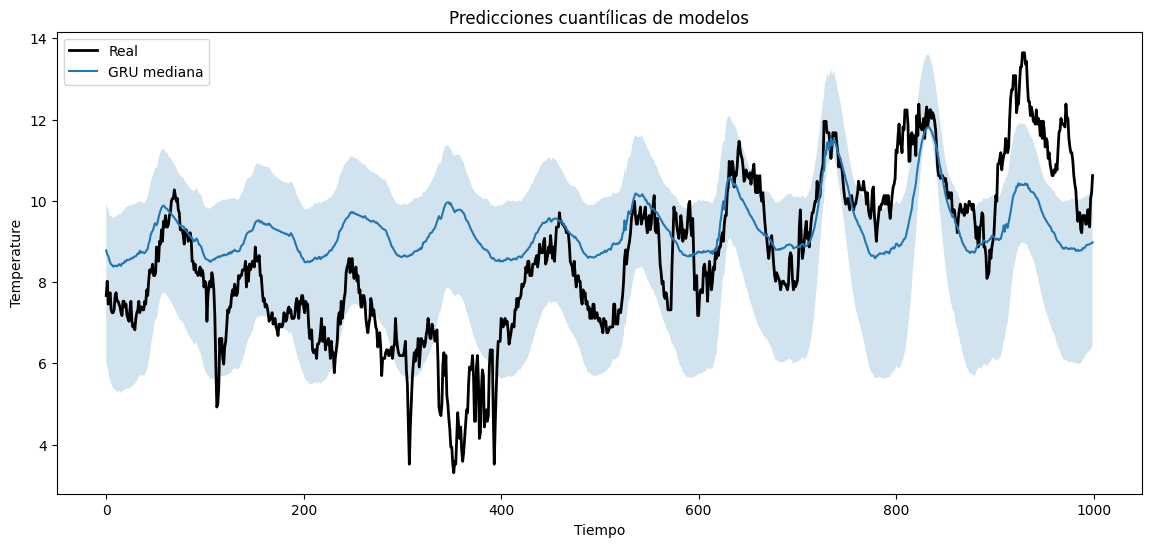

In [54]:
plot_models({'GRU': preds_dict['GRU']}, real_series=real_series_val, quantiles=[0.1,0.5,0.95], n_steps=1000, print_trhold=True)

Es destacable como la GRU predice especialmente bien algunos de los picos, además con un intervalo de confianza más estrecho que los modelos anteriores.  
En general, parece estar dando mejores resultados en esta muestra que la LSTM y pensando que GRU es un modelo menos costoso.

#### 5.4 Visualización de la TCN

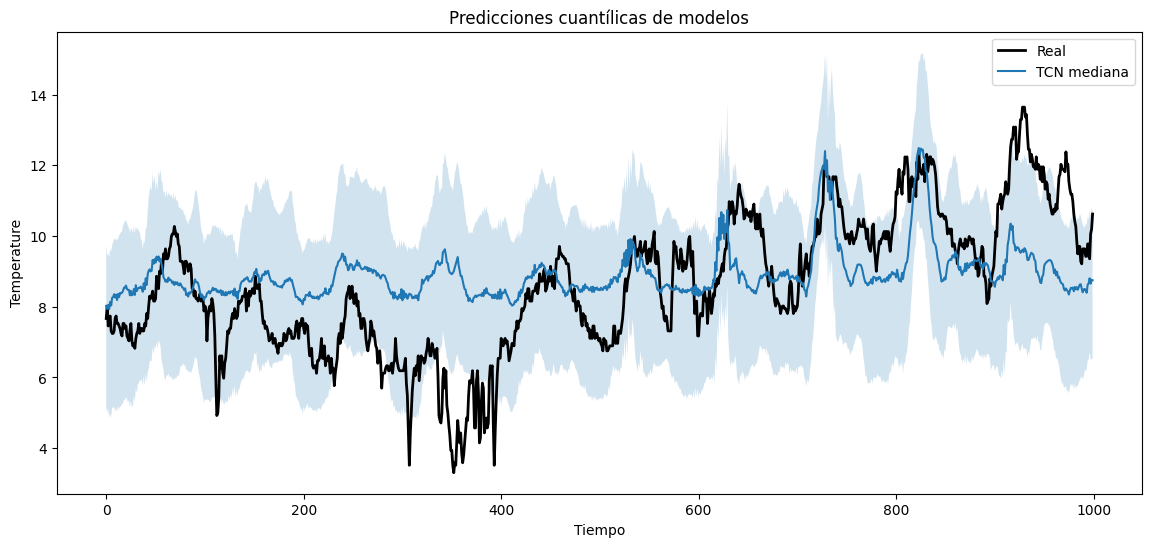

In [60]:
plot_models({'TCN': preds_dict['TCN']}, real_series=real_series_val, quantiles=[0.1,0.5,0.95], n_steps=1000, print_trhold=True)

De todos los modelos hasta ahora, la TCN es el que más se acerca al dato original en esta muestra de 1000 pasos. Es el que más cubre con el intervalo de confianza elegido al valor real.

#### 5.5 Visualización del Transformer

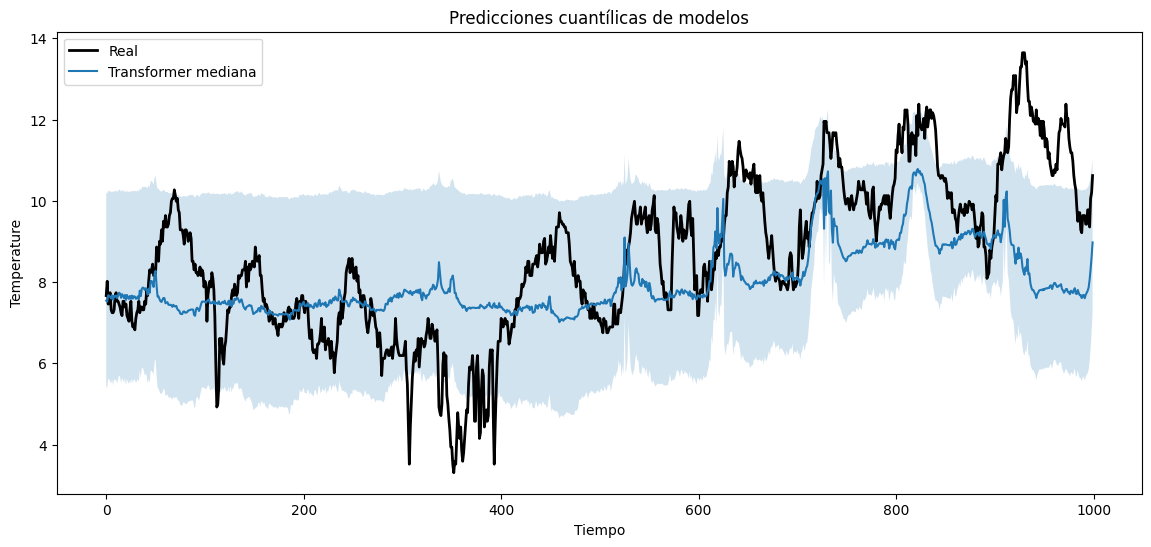

In [63]:
plot_models({'Transformer': preds_dict['Transformer']}, real_series=real_series_val, quantiles=[0.1,0.5,0.95], n_steps=1000, print_trhold=True)

Con diferencia, el Transformer es el modelo más conservador, es el que más franja cubre el intervalo de confianza.

## 6. Conclusiones

Si bien la predicciones que se han analizado no están demasiado lejos de los valores reales, solo se ha estudiado una muestra de 1000 valores de temperatura. Como futuro trabajo, valdría la pena revisar otros tramos o incluso estudiarlo con un conjunto de test que no se haya visto antes en el entrenamiento.  

Además, posiblemente sea beneficioso hacer un estudio más exhaustivo del conjunto de datos y definir variables que puedan llegar a dar una intuición o ayudar en el entrenamiento de estos picos que son los más difíciles de predecir (sobre todo cuando la temperatura desciende repentinamente).  

Otras modificaciones que han sido especialmente útiles ha sido el ajuste de hiperparámetros (sea learning rate, batch size, patience, ...). Cabe la posibilidad de seguir ajustando estos para llegar a mejores resultados.